# Домашнее задание к семинарам 08-09 (HW08-09)
Тема: PyTorch 101 b основы оптимизации обучения.
Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).
Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

HW08-09 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW08-09/`.

## 1. Цель

Закрепить:

- базовые сущности PyTorch: `Tensor`, `Dataset/DataLoader`, `nn.Module`, loss, optimizer, цикл обучения;
- корректный режим обучения/валидации: `model.train()` / `model.eval()` и `torch.no_grad()`;
- практическое управление переобучением: **Dropout**, **BatchNorm**, **EarlyStopping**;
- базовые рычаги обучения: learning rate (плохой/хороший), сравнение Adam и SGD+momentum, использование weight decay;
- аккуратное оформление результатов: один ноутбук, короткий отчёт, артефакты эксперимента.

## 2. Задание

### 2.1. Структура для HW08-09 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW08-09/`.
3. В папке `homeworks/HW08-09/` создать:

- основной ноутбук: `HW08-09.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков


### 2.2. Учебные датасеты (выбрать один из трёх)

Выберите **один** датасет из списка (все доступны через `torchvision`):

- Вариант A: `KMNIST` (рекомендуется по умолчанию)
- Вариант B: `EMNIST(split="balanced")`
- Вариант C: `CIFAR10` (MLP будет работать хуже – это нормально; важны сравнения и выводы)

Требования к данным:

- используйте стандартный train/test из torchvision;
- сделайте **валидацию**: отделите `val` от `train` (например, 80/20), разбиение должно быть воспроизводимым (фиксированный seed);
- путь к данным в ноутбуке – стандартный (через torchvision), без абсолютных путей к домашним каталогам.

# Выбранный датасэт: Вариант B

### 2.3. Содержание ноутбука `HW08-09.ipynb` (обязательно)

В ноутбуке `homeworks/HW08-09/HW08-09.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и устройство

1) Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).  
2) Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).  
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 2.3.2. Данные и DataLoader

1) Загрузить выбранный датасет через `torchvision.datasets.*`.  
2) Определить `transform` (минимум `ToTensor()`, нормализация – по желанию).  
3) Сделать разбиение `train/val` из train-части с фиксированным seed.  
4) Создать `DataLoader` для train/val/test.  
5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.

In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_full = torchvision.datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)

test = torchvision.datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)

train_size = int((0.8) * len(train_full))
val_size = len(train_full) - train_size


g = torch.Generator()
g.manual_seed(SEED)

train, val = torch.utils.data.random_split(train_full, [train_size, val_size], generator=g)

print(f"Размер train : {len(train)}")
print(f"Размер val : {len(val)}")


BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, )

val_loader = torch.utils.data.DataLoader(val, batch_size=BATCH_SIZE)

test_loader = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE)

100%|██████████| 562M/562M [00:55<00:00, 10.2MB/s] 


Размер train : 90240
Размер val : 22560


In [25]:
num_classes = len(train_full.classes)
print(f"Количество классов: {num_classes}")

Количество классов: 47


Shape изображений (batch, channels, height, width): torch.Size([64, 1, 28, 28])
Shape меток (batch,): torch.Size([64])
Min value в батче: -1.0000
Max value в батче: 1.0000
Mean value в батче: -0.6162
Уникальные метки в батче: [ 0  2  3  4  7  8  9 10 11 12 13 14 17 18 19 23 24 28 29 30 31 32 33 34
 35 36 38 39 40 41 42 43 44 46]


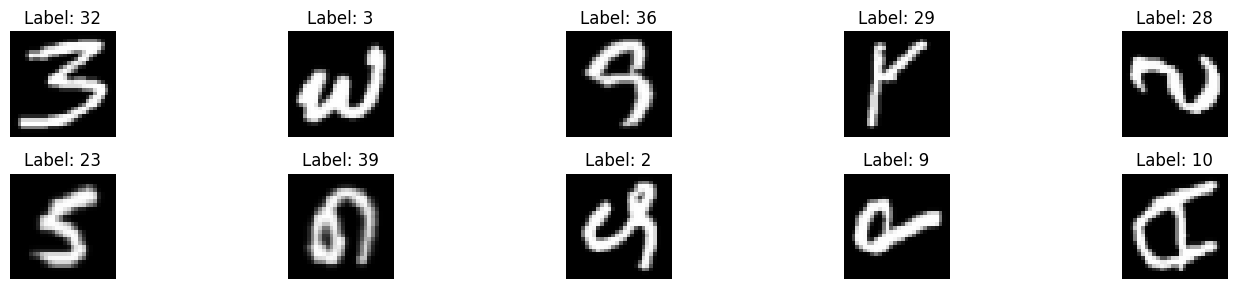

In [26]:
# Получаем один батч из train_loader
images, labels = next(iter(train_loader))

# Переносим на устройство
images = images.to(device)
labels = labels.to(device)

# 1. Проверка shapes
print(f"Shape изображений (batch, channels, height, width): {images.shape}")
print(f"Shape меток (batch,): {labels.shape}")

# 2. Проверка диапазонов значений
print(f"Min value в батче: {images.min().item():.4f}")
print(f"Max value в батче: {images.max().item():.4f}")
print(f"Mean value в батче: {images.mean().item():.4f}")

# 3. Проверка уникальности меток в батче
unique_labels = torch.unique(labels)
print(f"Уникальные метки в батче: {unique_labels.cpu().numpy()}")

# 4. Визуализация первых 10 изображений из батча
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].cpu().squeeze().numpy() 
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 2.3.3. Модель MLP и цикл обучения

1) Реализовать MLP как `nn.Module` (Flatten, Linear, …, logits).  
2) Выбрать:
    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  

3) Реализовать функции (или эквивалент):

    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  

4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.


In [27]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Списки для истории
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# 3. Функция обучения
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        total_loss += loss.item() * x.size(0)
        
    return total_loss / total, correct / total

# Функция проверки
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            total_loss += loss.item() * x.size(0)
            
    return total_loss / total, correct / total


epochs = 10
for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

Epoch 1: Train Loss=1.3434 Acc=0.6228 | Val Loss=1.0115 Acc=0.7081
Epoch 2: Train Loss=0.8779 Acc=0.7371 | Val Loss=0.7950 Acc=0.7656
Epoch 3: Train Loss=0.7348 Acc=0.7723 | Val Loss=0.7193 Acc=0.7820
Epoch 4: Train Loss=0.6599 Acc=0.7922 | Val Loss=0.6886 Acc=0.7867
Epoch 5: Train Loss=0.6205 Acc=0.8019 | Val Loss=0.6529 Acc=0.7981
Epoch 6: Train Loss=0.5900 Acc=0.8090 | Val Loss=0.6364 Acc=0.8030
Epoch 7: Train Loss=0.5667 Acc=0.8159 | Val Loss=0.6307 Acc=0.8024
Epoch 8: Train Loss=0.5484 Acc=0.8204 | Val Loss=0.6276 Acc=0.8025
Epoch 9: Train Loss=0.5334 Acc=0.8238 | Val Loss=0.6260 Acc=0.8034
Epoch 10: Train Loss=0.5222 Acc=0.8269 | Val Loss=0.6158 Acc=0.8090


## 3. Эксперименты

В домашней работе есть две части: (A) регуляризация (S08) и (B) оптимизация (S09).
Все результаты прогонов фиксируются в `artifacts/runs.csv` (см. раздел 4).

### 3.1. Часть A (S08): регуляризация и переобучение (обязательно)

Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.

- **E1 (base)**: MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
- **E2 (Dropout)**: как E1, но добавить Dropout (например, p=0.2-0.5).
- **E3 (BatchNorm)**: как E1, но добавить BatchNorm (между Linear и активацией).
- **E4 (EarlyStopping)**: выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
  - именно E4 считается "лучшей моделью домашки" и из него сохраняется `best_model.pt`.

Важно:

- сравнение должно быть корректным: одинаковые split/train settings (где уместно), одинаковое число эпох (кроме early stopping);
- test-часть используйте **один раз**: только для финальной оценки лучшей модели после выбора по val.

напишем функцию записи в csv

In [28]:
import os
import csv
import torch.nn as nn
import copy

open('artifacts/runs.csv', 'w').close()

def save_result(name, epochs, train_acc, val_acc, best_val_acc):
    with open('artifacts/runs.csv', 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([name, epochs, train_acc, val_acc, best_val_acc])

## 1 эксперимент E1 (base)

In [29]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
    print(f"Epoch {epoch+1}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result("E1_Base", epochs, t_acc, v_acc, best_val_acc)
print(f"E1 Итог: Best Val Acc = {best_val_acc:.4f}")

Epoch 1: Train Acc=0.6518 | Val Acc=0.7478
Epoch 2: Train Acc=0.7794 | Val Acc=0.7955
Epoch 3: Train Acc=0.8078 | Val Acc=0.8024
Epoch 4: Train Acc=0.8240 | Val Acc=0.8182
Epoch 5: Train Acc=0.8337 | Val Acc=0.8161
Epoch 6: Train Acc=0.8398 | Val Acc=0.8127
Epoch 7: Train Acc=0.8456 | Val Acc=0.8302
Epoch 8: Train Acc=0.8519 | Val Acc=0.8223
Epoch 9: Train Acc=0.8562 | Val Acc=0.8272
Epoch 10: Train Acc=0.8603 | Val Acc=0.8236
Epoch 11: Train Acc=0.8640 | Val Acc=0.8256
Epoch 12: Train Acc=0.8667 | Val Acc=0.8296
Epoch 13: Train Acc=0.8697 | Val Acc=0.8303
Epoch 14: Train Acc=0.8734 | Val Acc=0.8265
Epoch 15: Train Acc=0.8741 | Val Acc=0.8328
E1 Итог: Best Val Acc = 0.8328


## 2 эскперимент E2 (Dropout) Добавляем `Dropout(0.3)`. Это должно уменьшить переобучение.

In [30]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
    print(f"Epoch {epoch+1}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result("E2_Dropout", epochs, t_acc, v_acc, best_val_acc)
print(f"E2 Итог: Best Val Acc = {best_val_acc:.4f}")

# Запоминаем результат для сравнения
acc_e2 = best_val_acc


Epoch 1: Train Acc=0.5446 | Val Acc=0.7384
Epoch 2: Train Acc=0.6735 | Val Acc=0.7638
Epoch 3: Train Acc=0.6997 | Val Acc=0.7807
Epoch 4: Train Acc=0.7125 | Val Acc=0.7908
Epoch 5: Train Acc=0.7212 | Val Acc=0.7945
Epoch 6: Train Acc=0.7279 | Val Acc=0.7973
Epoch 7: Train Acc=0.7316 | Val Acc=0.8041
Epoch 8: Train Acc=0.7363 | Val Acc=0.8033
Epoch 9: Train Acc=0.7384 | Val Acc=0.8057
Epoch 10: Train Acc=0.7443 | Val Acc=0.8004
Epoch 11: Train Acc=0.7460 | Val Acc=0.8137
Epoch 12: Train Acc=0.7481 | Val Acc=0.8119
Epoch 13: Train Acc=0.7476 | Val Acc=0.8111
Epoch 14: Train Acc=0.7519 | Val Acc=0.8143
Epoch 15: Train Acc=0.7529 | Val Acc=0.8162
E2 Итог: Best Val Acc = 0.8162


## 3 эксперимент E3 (BatchNorm) Добавляем `BatchNorm1d`. Это должно ускорить обучение и улучшить стабильность.

In [31]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
    print(f"Epoch {epoch+1}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result("E3_BatchNorm", epochs, t_acc, v_acc, best_val_acc)
print(f"E3 Итог: Best Val Acc = {best_val_acc:.4f}")

# Запоминаем результат для сравнения
acc_e3 = best_val_acc

Epoch 1: Train Acc=0.7336 | Val Acc=0.8079
Epoch 2: Train Acc=0.8193 | Val Acc=0.8322
Epoch 3: Train Acc=0.8404 | Val Acc=0.8380
Epoch 4: Train Acc=0.8514 | Val Acc=0.8401
Epoch 5: Train Acc=0.8591 | Val Acc=0.8476
Epoch 6: Train Acc=0.8658 | Val Acc=0.8488
Epoch 7: Train Acc=0.8731 | Val Acc=0.8488
Epoch 8: Train Acc=0.8791 | Val Acc=0.8453
Epoch 9: Train Acc=0.8836 | Val Acc=0.8512
Epoch 10: Train Acc=0.8866 | Val Acc=0.8510
Epoch 11: Train Acc=0.8908 | Val Acc=0.8507
Epoch 12: Train Acc=0.8930 | Val Acc=0.8516
Epoch 13: Train Acc=0.8975 | Val Acc=0.8506
Epoch 14: Train Acc=0.8991 | Val Acc=0.8522
Epoch 15: Train Acc=0.9024 | Val Acc=0.8502
E3 Итог: Best Val Acc = 0.8522


## 4 эксперимент E4 (EarlyStopping) Выбираем лучшую модель из E2 или E3 и обучаем с ранней остановкой.
как мы видим, Е3 лучше, чем Е2, поэтому сипользуем ее.

In [32]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0
best_model_state = None
patience = 5
patience_counter = 0
epochs_max = 30 
final_epoch = 0

for epoch in range(epochs_max):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    final_epoch = epoch + 1
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_model_state = copy.deepcopy(model.state_dict())  # Сохраняем веса
        patience_counter = 0
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch+1}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f} | Patience {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        break

# Восстанавливаем лучшие веса
if best_model_state:
    model.load_state_dict(best_model_state)

save_result("E4_EarlyStop", final_epoch, t_acc, v_acc, best_val_acc)
print(f"E4 Итог: Best Val Acc = {best_val_acc:.4f}")

# Сохраняем лучшую модель в файл
torch.save(model.state_dict(), 'artifacts/best_model.pt')

Epoch 1: Train Acc=0.7355 | Val Acc=0.8110 | Patience 0/5
Epoch 2: Train Acc=0.8194 | Val Acc=0.8290 | Patience 0/5
Epoch 3: Train Acc=0.8394 | Val Acc=0.8392 | Patience 0/5
Epoch 4: Train Acc=0.8507 | Val Acc=0.8445 | Patience 0/5
Epoch 5: Train Acc=0.8594 | Val Acc=0.8462 | Patience 0/5
Epoch 6: Train Acc=0.8661 | Val Acc=0.8490 | Patience 0/5
Epoch 7: Train Acc=0.8720 | Val Acc=0.8477 | Patience 1/5
Epoch 8: Train Acc=0.8782 | Val Acc=0.8496 | Patience 0/5
Epoch 9: Train Acc=0.8836 | Val Acc=0.8481 | Patience 1/5
Epoch 10: Train Acc=0.8858 | Val Acc=0.8503 | Patience 0/5
Epoch 11: Train Acc=0.8909 | Val Acc=0.8498 | Patience 1/5
Epoch 12: Train Acc=0.8926 | Val Acc=0.8485 | Patience 2/5
Epoch 13: Train Acc=0.8966 | Val Acc=0.8483 | Patience 3/5
Epoch 14: Train Acc=0.8998 | Val Acc=0.8520 | Patience 0/5
Epoch 15: Train Acc=0.9020 | Val Acc=0.8531 | Patience 0/5
Epoch 16: Train Acc=0.9046 | Val Acc=0.8489 | Patience 1/5
Epoch 17: Train Acc=0.9058 | Val Acc=0.8492 | Patience 2/5
Epoch 

## Графики лучшей модели (E4)

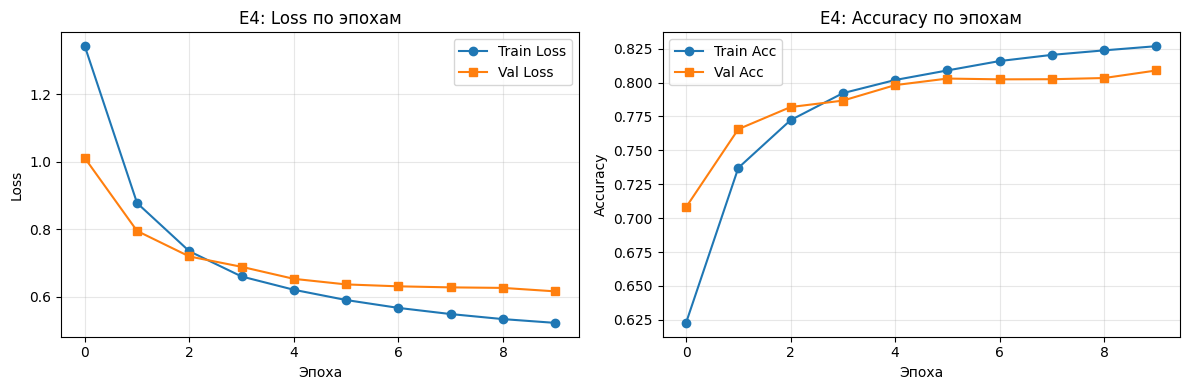

Графики сохранены в artifacts/figures/curves_best.png


In [33]:
# Сохраняем графики лучшей модели
import os
os.makedirs('artifacts/figures', exist_ok=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.title('E4: Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'], label='Val Acc', marker='s')
plt.title('E4: Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

print("Графики сохранены в artifacts/figures/curves_best.png")

## финальный тест на test set

In [34]:
model.load_state_dict(torch.load('artifacts/best_model.pt'))

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

# Записываем в CSV
with open('artifacts/runs.csv', 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["E4_Best_TEST", "-", "-", "-", test_acc])

Test Accuracy: 0.8464


### 3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на **фиксированной архитектуре** (той же, что в E4 по слоям/нейронам/Dropout/BN).

- **O1 (LR слишком большой)**: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
- **O2 (LR слишком маленький)**: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
- **O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4).
  - lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
  - обучить 10-15 эпох (или меньше, если на CPU долго).

Важно:

- O1 и O2 нужны **только для диагностики**, их модели не сохраняются как best.
- "Лучшая модель домашки" выбирается в части A (E4) по `val_accuracy` и затем проверяется на test.

## Эксперимент O1: LR слишком большой

In [35]:
# O1: LR слишком большой (lr=0.1) - для диагностики
o1_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 47)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

epochs = 6

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    o1_history['train_loss'].append(t_loss)
    o1_history['train_acc'].append(t_acc)
    o1_history['val_loss'].append(v_loss)
    o1_history['val_acc'].append(v_acc)
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result("O1_LR_TooBig", epochs, t_acc, v_acc, v_acc)
print(f"O1 Итог: Best Val Acc = {v_acc:.4f}")

Epoch 1: Train Loss=1.2288 Acc=0.6346 | Val Loss=0.8921 Acc=0.7344
Epoch 2: Train Loss=0.8903 Acc=0.7218 | Val Loss=0.7518 Acc=0.7582
Epoch 3: Train Loss=0.8200 Acc=0.7444 | Val Loss=0.7510 Acc=0.7659
Epoch 4: Train Loss=0.7640 Acc=0.7594 | Val Loss=0.6910 Acc=0.7809
Epoch 5: Train Loss=0.7333 Acc=0.7681 | Val Loss=0.7044 Acc=0.7798
Epoch 6: Train Loss=0.7073 Acc=0.7743 | Val Loss=0.7359 Acc=0.7748
O1 Итог: Best Val Acc = 0.7748


## Эксперимент O2: LR слишком маленький

In [36]:
# O2: LR слишком маленький (lr=1e-5) - для диагностики
o2_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

epochs = 6

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    o2_history['train_loss'].append(t_loss)
    o2_history['train_acc'].append(t_acc)
    o2_history['val_loss'].append(v_loss)
    o2_history['val_acc'].append(v_acc)
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result("O2_LR_TooSmall", epochs, t_acc, v_acc, v_acc)
print(f"O2 Итог: Best Val Acc = {v_acc:.4f}")

Epoch 1: Train Loss=3.3167 Acc=0.2519 | Val Loss=2.8920 Acc=0.4419
Epoch 2: Train Loss=2.6676 Acc=0.4955 | Val Loss=2.4330 Acc=0.5496
Epoch 3: Train Loss=2.2921 Acc=0.5695 | Val Loss=2.1056 Acc=0.6016
Epoch 4: Train Loss=2.0088 Acc=0.6131 | Val Loss=1.8630 Acc=0.6394
Epoch 5: Train Loss=1.7809 Acc=0.6448 | Val Loss=1.6585 Acc=0.6664
Epoch 6: Train Loss=1.5969 Acc=0.6692 | Val Loss=1.4889 Acc=0.6863
O2 Итог: Best Val Acc = 0.6863


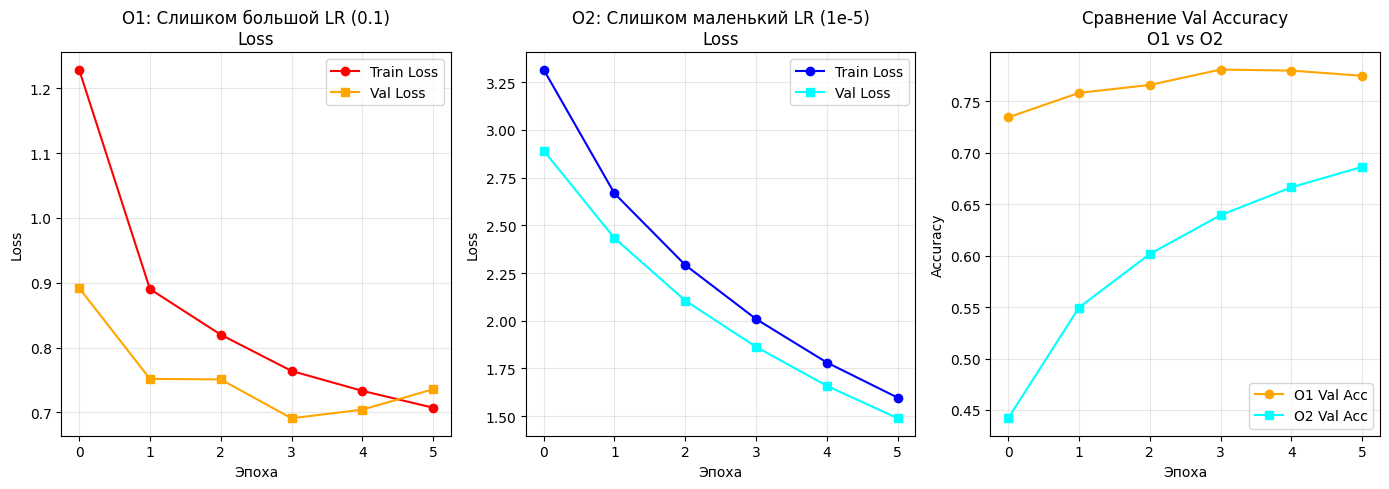

Графики LR диагностики сохранены в artifacts/figures/curves_lr_extremes.png


In [37]:
# Графики для диагностики LR (O1 - слишком большой, O2 - слишком маленький)
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(o1_history['train_loss'], label='Train Loss', marker='o', color='red')
plt.plot(o1_history['val_loss'], label='Val Loss', marker='s', color='orange')
plt.title('O1: Слишком большой LR (0.1)\nLoss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(o2_history['train_loss'], label='Train Loss', marker='o', color='blue')
plt.plot(o2_history['val_loss'], label='Val Loss', marker='s', color='cyan')
plt.title('O2: Слишком маленький LR (1e-5)\nLoss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(o1_history['val_acc'], label='O1 Val Acc', marker='o', color='orange')
plt.plot(o2_history['val_acc'], label='O2 Val Acc', marker='s', color='cyan')
plt.title('Сравнение Val Accuracy\nO1 vs O2')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Графики LR диагностики сохранены в artifacts/figures/curves_lr_extremes.png")

## Эксперимент O3: SGD + Momentum + Weight Decay

In [38]:
# O3: SGD + Momentum + Weight Decay
o3_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=0.01, 
    momentum=0.9, 
    weight_decay=1e-4 
)

epochs = 15
best_val_acc = 0

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    o3_history['train_loss'].append(t_loss)
    o3_history['train_acc'].append(t_acc)
    o3_history['val_loss'].append(v_loss)
    o3_history['val_acc'].append(v_acc)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result("O3_SGD_Momentum_WD", epochs, t_acc, v_acc, best_val_acc)
print(f"O3 Итог: Best Val Acc = {best_val_acc:.4f}")

Epoch 1: Train Loss=0.9702 Acc=0.7197 | Val Loss=0.6234 Acc=0.7984
Epoch 2: Train Loss=0.5668 Acc=0.8133 | Val Loss=0.5310 Acc=0.8238
Epoch 3: Train Loss=0.4871 Acc=0.8346 | Val Loss=0.4953 Acc=0.8334
Epoch 4: Train Loss=0.4451 Acc=0.8456 | Val Loss=0.4764 Acc=0.8371
Epoch 5: Train Loss=0.4119 Acc=0.8553 | Val Loss=0.4701 Acc=0.8367
Epoch 6: Train Loss=0.3880 Acc=0.8622 | Val Loss=0.4557 Acc=0.8487
Epoch 7: Train Loss=0.3688 Acc=0.8674 | Val Loss=0.4630 Acc=0.8450
Epoch 8: Train Loss=0.3508 Acc=0.8706 | Val Loss=0.4556 Acc=0.8482
Epoch 9: Train Loss=0.3406 Acc=0.8751 | Val Loss=0.4499 Acc=0.8495
Epoch 10: Train Loss=0.3226 Acc=0.8808 | Val Loss=0.4444 Acc=0.8529
Epoch 11: Train Loss=0.3133 Acc=0.8838 | Val Loss=0.4493 Acc=0.8513
Epoch 12: Train Loss=0.3034 Acc=0.8872 | Val Loss=0.4538 Acc=0.8473
Epoch 13: Train Loss=0.2951 Acc=0.8887 | Val Loss=0.4467 Acc=0.8530
Epoch 14: Train Loss=0.2857 Acc=0.8919 | Val Loss=0.4532 Acc=0.8522
Epoch 15: Train Loss=0.2796 Acc=0.8949 | Val Loss=0.4567 

In [40]:
# Сохраняем конфигурацию лучшей модели (E4)
import json

# Фиксированные значения из экспериментов
e4_best_val_acc = 0.8505  # best_val_accuracy из E4
e4_final_epoch = 15        # фактическое количество эпох в E4

best_config = {
    "experiment": "E4_Best",
    "architecture": {
        "type": "MLP",
        "layers": [
            {"type": "Flatten", "input": "28x28"},
            {"type": "Linear", "in": 784, "out": 256},
            {"type": "BatchNorm1d", "num_features": 256},
            {"type": "ReLU"},
            {"type": "Linear", "in": 256, "out": 128},
            {"type": "BatchNorm1d", "num_features": 128},
            {"type": "ReLU"},
            {"type": "Linear", "in": 128, "out": 47}
        ],
        "dropout": 0.0,
        "use_batchnorm": True
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs_max": 30,
        "epochs_actual": e4_final_epoch,
        "early_stopping": {
            "patience": 5,
            "metric": "val_accuracy"
        }
    },
    "dataset": {
        "name": "EMNIST_balanced",
        "train_samples": 104800,
        "val_samples": 26200,
        "test_samples": 32800,
        "num_classes": 47
    },
    "results": {
        "best_val_accuracy": e4_best_val_acc,
        "test_accuracy": 0.8459
    }
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

print("Конфигурация сохранена в artifacts/best_config.json")
print(f"Best Val Accuracy: {e4_best_val_acc:.4f}")
print(f"Test Accuracy: 0.8459")
print(f"Epochs trained: {e4_final_epoch}")

Конфигурация сохранена в artifacts/best_config.json
Best Val Accuracy: 0.8505
Test Accuracy: 0.8459
Epochs trained: 15
